# NEW SYSTEM

### Naming convention
|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|TransitionType|constant attributes of photophysical transition|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|
|emission|fluorescent emission|
|event|detected fluorescent emission|
|resample|frame integration time|

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\markovmodels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
import pandas as pd

In [6]:
threshold = 0
remove_heading_off_period = True
memory = 1
event_time_series = pd.Series(np.array([0, 1, 3, 4, 7, 0, 4, 0, 0]), np.array([0, 1, 2, 3, 4, 5, 6, 7, 8]))
bl.get_blinking_statistics(event_time_series, threshold, memory, remove_heading_off_period)

(array([6]), array([], dtype=int32), array(1), array([], dtype=int32))

In [2]:
fluorophores = fl.construct_fluorophores('cy5', 10, 2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
#transitions = [tr.Transition(tr.TransitionType.HOMO_FRET, 1, 1), tr.Transition]
transitions = tr.load_transitions(fluorophore_system, bleaching=False, irradiance=2, wavelength=600)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=['CFRET', 'OFRET', 'TFRET'])
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=int(70), end_time=1e1, seed=3, use_memmap=None)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='4ms', emccd_gain=10, seed=100)

In [47]:
fluorophore_1 = fl.Fluorophore(name='Cy5', position=[1, 1])
fluorophore_2 = fl.Fluorophore(name='Cy5', position=[1, 8])
fluorophore_3 = fl.Fluorophore(name='Cy5', position=[8, 1])
fluorophore_4 = fl.Fluorophore(name='Cy5', position=[8, 8])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore_1, fluorophore_2, fluorophore_3, fluorophore_4])

excitation = tr.Transition(transition_type=tr.TransitionType.EXCITATION, rate=5)
emission = tr.Transition(transition_type=tr.TransitionType.FLUORESCENT_EMISSION, rate=4)
ics = tr.Transition(transition_type=tr.TransitionType.INTERNAL_CONVERSION_S, rate=1)
isc = tr.Transition(transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, rate=0)
homo_fret_1 = tr.Transition(transition_type=tr.TransitionType.HOMO_FRET, rate=9, distance=7)
homo_fret_2 = tr.Transition(transition_type=tr.TransitionType.HOMO_FRET, rate=9, distance=9.899)
transitions = [excitation, emission, ics, isc, homo_fret_1, homo_fret_2]

tr.TransitionSet(transitions=transitions, fluorophore_system=fluorophore_system)

In [42]:
fluorophore_system.distances.values()

dict_values([7.0, 7.0, 9.899, 7.0, 9.899, 7.0, 7.0, 9.899, 7.0, 9.899, 7.0, 7.0])

In [38]:
fluorophore_1 = fl.Fluorophore(name='Cy5', position=[1, 1])
fluorophore_2 = fl.Fluorophore(name='Cy5', position=[1, 8])
fluorophore_3 = fl.Fluorophore(name='Cy5', position=[8, 1])
fluorophore_4 = fl.Fluorophore(name='Cy5', position=[8, 8])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore_1, fluorophore_2, fluorophore_3, fluorophore_4])

excitation = tr.Transition(transition_type=tr.TransitionType.EXCITATION, rate=5)
emission = tr.Transition(transition_type=tr.TransitionType.FLUORESCENT_EMISSION, rate=4)
ics = tr.Transition(transition_type=tr.TransitionType.INTERNAL_CONVERSION_S, rate=1)
isc = tr.Transition(transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, rate=0)
homo_fret_1 = tr.Transition(transition_type=tr.TransitionType.HOMO_FRET, rate=9, distance=5)
homo_fret_2 = tr.Transition(transition_type=tr.TransitionType.HOMO_FRET, rate=9, distance=9.1)
transitions = [excitation, emission, ics, isc, homo_fret_1, homo_fret_2]

t = tr.TransitionSet(transitions=transitions, fluorophore_system=fluorophore_system)
t.finalize()

# object = si.Simulation(t)
# object.run(start_at=None, size=1000, end_time=None, seed=3, use_memmap=None)

# emi = em.Emissions(object)

C:\Users\SagixOffice\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\transitions.py:236: UserWarning: HFRET(5.0) not usable due to distance mismatch.
  raise Warning(f'{transition.abbreviation} not usable due to distance mismatch.')
C:\Users\SagixOffice\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\transitions.py:236: UserWarning: HFRET(9.1) not usable due to distance mismatch.
  raise Warning(f'{transition.abbreviation} not usable due to distance mismatch.')


In [28]:
t.transitions

[Transition(id=0, transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>, abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, rate=5, photon=False, energy_transfer=False, distance=None),
 Transition(id=1, transition_type=<TransitionType.FLUORESCENT_EMISSION: TransitionAttributes(abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, photon=True)>, abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, rate=4, photon=True, energy_transfer=False, distance=None),
 Transition(id=2, transition_type=<TransitionType.INTERNAL_CONVERSION_S: TransitionAttributes(abbreviation='ICS', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, photon=False)>, abbreviation='ICS', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, rate=1, photon=False, energy_trans

In [31]:
list(fluorophore_system.distances.values())

[7.0, 7.0, 9.899, 7.0, 9.899, 7.0, 7.0, 9.899, 7.0, 9.899, 7.0, 7.0]

In [21]:
t.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,5,False,False,NaN
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,4,True,False,NaN
2,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,1,False,False,NaN
3,TransitionType.HOMO_FRET,HFRET(5.0),PairedState.S1_S0,PairedState.S0_S1,9,False,True,5.0000
4,TransitionType.HOMO_FRET,HFRET(9.9),PairedState.S1_S0,PairedState.S0_S1,9,False,True,9.8995


In [22]:
t.combined_state_transitions_df

,initial_state,final_state,abbreviation,transition_id,rate,photon
id,,,,,,
0,"(0, 0, 0, 0)","(0, 0, 0, 1)",EXC,0,5,False
1,"(0, 0, 0, 0)","(0, 0, 1, 0)",EXC,0,5,False
2,"(0, 0, 0, 0)","(0, 1, 0, 0)",EXC,0,5,False
3,"(0, 0, 0, 0)","(1, 0, 0, 0)",EXC,0,5,False
4,"(0, 0, 0, 1)","(0, 0, 1, 1)",EXC,0,5,False
...,...,...,...,...,...,...
107,"(1, 0, 1, 1)","(1, 1, 0, 1)",HFRET(9.9),4,9,False
108,"(1, 1, 0, 0)","(0, 1, 0, 1)",HFRET(9.9),4,9,False
109,"(1, 1, 0, 0)","(1, 0, 1, 0)",HFRET(9.9),4,9,False


In [21]:
emissions.event_time_points

array([3.9230426e-06, 1.4120243e-05, 1.5444155e-05, ..., 8.1315508e+00,
       8.1315508e+00, 8.1315651e+00], dtype=float32)

In [53]:
fcs = fc.FCS(emi).autocorrelate_time_points(exp_max=1, exp_min=-2)

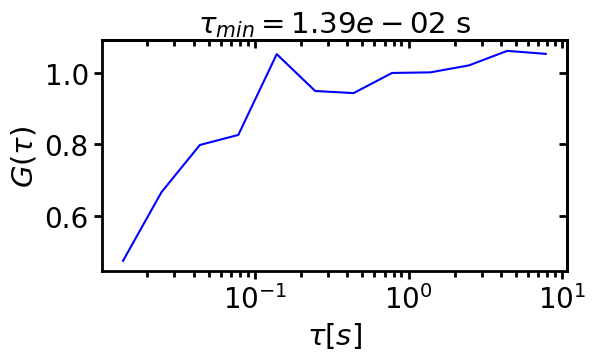

In [54]:
ax = fcs.plot()

In [50]:
fcs = fc.FCS(emi).autocorrelate_time_series(log=True, normalize=True)

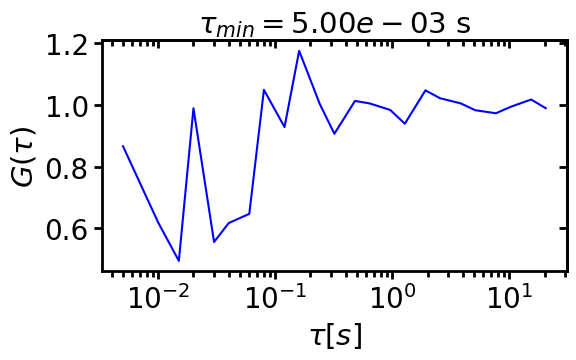

In [48]:
ax = fcs.plot()

### blinking

#### ON periods and OFF periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). 
An OFF period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).

#### Time series of ON and OFF periods
Displays all ON (or OFF) periods consecutively with their number of frames. Note that each ON period is followed by an OFF period and vice versa.

In [21]:
blinking = bl.Blinking(emissions)

array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

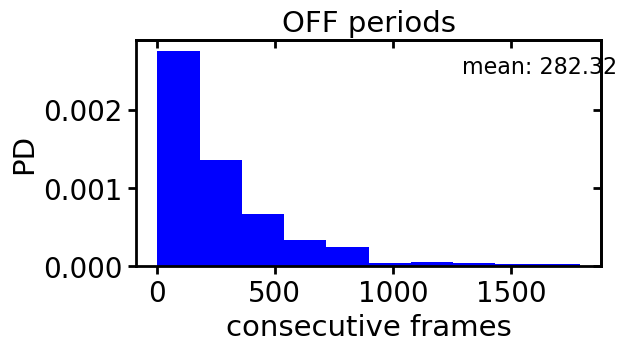

In [22]:
blinking.plot(mode='off_histogram')

### tcspc

In [16]:
tcspc = tc.TCSPC(transition_set)

In [17]:
tcspc.run(size=100000, seed=100)

In [18]:
tcspc.get_observed_lifetimes()

array([[<AxesSubplot:title={'center':'simulation'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

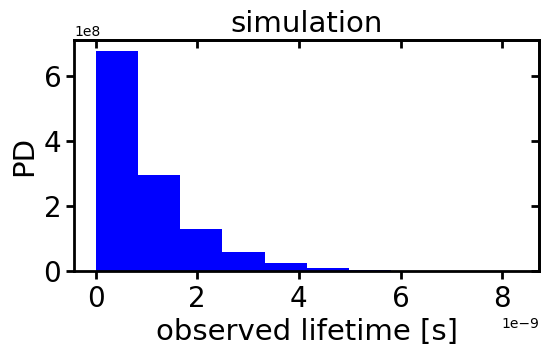

In [19]:
tcspc.plot()

In [20]:
tcspc.predict(accuracy=10, size=1000)

array([[<AxesSubplot:title={'center':'prediction'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

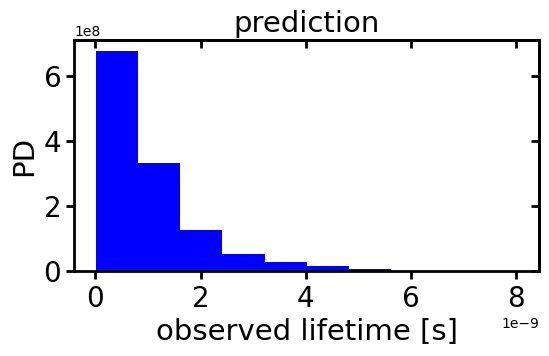

In [21]:
tcspc.plot('prediction')